# US Beverage-Alcohol Category Demand Forecasting
### A Time Series Analysis & Forecasting Project for FMCG/Beverage Demand Planning

**Author:** Naveen Thrikoshery Radhakrishnan
**Data source:** U.S. Census Bureau, Monthly Retail Trade Survey — Retail Sales: Beer, Wine, and Liquor Stores (NAICS 4453), via FRED (Federal Reserve Economic Data), series `MRTSSM4453USN`

---

## Business Problem

A demand planner in the beverage-alcohol industry (e.g., at a company like Diageo) needs to monitor **category-level demand signals** alongside brand-specific POS data — is the overall market growing or shrinking, is a seasonal spike coming, and how much forecast uncertainty should size the safety stock buffer?

This project uses real, publicly available U.S. retail sales data for the beer/wine/liquor category as a demand signal, and walks through a complete demand planning workflow:

1. Exploratory data analysis
2. Time series decomposition (classical vs. STL, additive vs. multiplicative)
3. Stationarity testing and differencing
4. Baseline forecasting models (Naive, Moving Average, Exponential Smoothing, Holt's Method)
5. ARIMA and SARIMA modeling
6. Model evaluation (MAE, RMSE, MAPE) and selection
7. Safety stock calculation for inventory planning

**Scope note:** this dataset is a national, category-level aggregate (all beer+wine+liquor combined), not a single SKU or brand. The same methodology applies directly at brand/SKU level; a natural extension (flagged in the conclusion) is SKU-tier segmentation using clustering methods once multiple product-level series are available.


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.2

df = pd.read_csv('beer_wine_liquor_sales.csv', parse_dates=['date'], index_col='date')
df.index.freq = 'MS'
print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Missing values: {df['sales_millions'].isna().sum()}")
df.head()


Shape: (414, 1)
Date range: 1992-01-01 00:00:00 to 2026-06-01 00:00:00
Missing values: 0


,sales_millions
date,
1992-01-01,1414
1992-02-01,1444
1992-03-01,1496
1992-04-01,1569
1992-05-01,1707


## 2. Exploratory Data Analysis

**Business question:** what does the raw, unmodified data tell us before any statistical technique is applied?

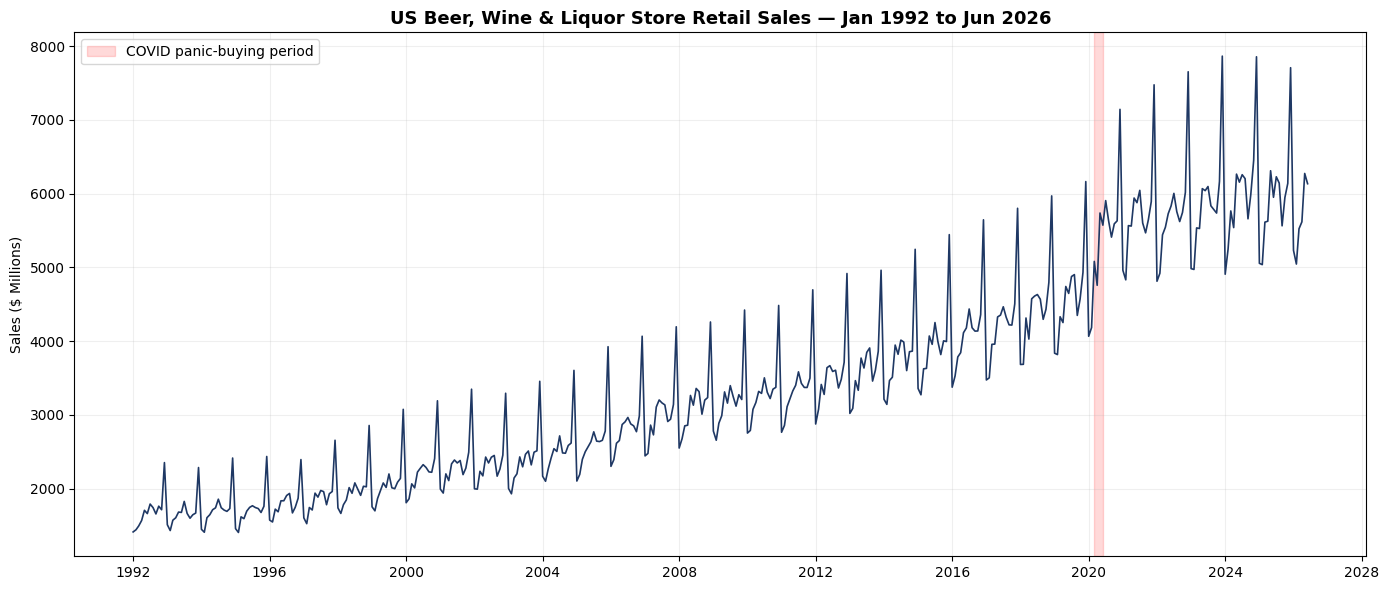

count     414.000000
mean     3421.685990
std      1482.650825
min      1407.000000
25%      2178.250000
50%      3180.000000
75%      4352.000000
max      7863.000000
Name: sales_millions, dtype: float64


In [2]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df['sales_millions'], color='#1F3864', linewidth=1.2)
ax.set_title("US Beer, Wine & Liquor Store Retail Sales — Jan 1992 to Jun 2026", fontsize=13, fontweight='bold')
ax.set_ylabel("Sales ($ Millions)")
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-06-01'), alpha=0.15, color='red', label='COVID panic-buying period')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('outputs_raw_series.png', dpi=150)
plt.show()

print(df['sales_millions'].describe())


**Observations:**
- A clear, sustained upward trend across 34 years (roughly tripling from ~$1,400M/month to ~$6,000M+/month)
- Unmistakable, consistent December seasonal spikes every year
- A visible anomaly around March–June 2020 (COVID panic-buying)

For the modeling work below, we restrict to a **recent window (2020–2026)** — long enough for 6+ full seasonal cycles, but more representative of current market conditions than 34-year-old data.

Working window shape: (78, 1)


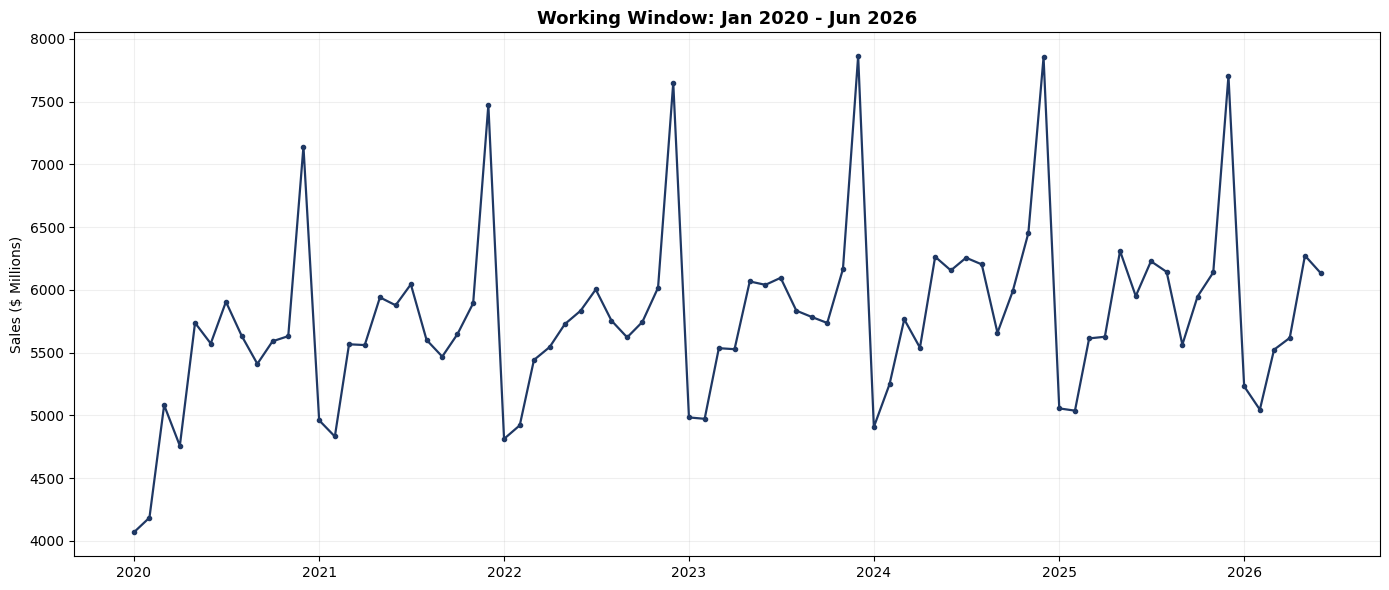

In [3]:
df_recent = df.loc['2020-01-01':'2026-06-01'].copy()
print(f"Working window shape: {df_recent.shape}")

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_recent.index, df_recent['sales_millions'], color='#1F3864', linewidth=1.6, marker='o', markersize=3)
ax.set_title("Working Window: Jan 2020 - Jun 2026", fontsize=13, fontweight='bold')
ax.set_ylabel("Sales ($ Millions)")
plt.tight_layout()
plt.savefig('outputs_working_window.png', dpi=150)
plt.show()


## 3. Time Series Decomposition

**Business question:** is the growth we see genuine, sustained category growth (trend), or mostly the predictable seasonal calendar? We compare two decomposition methods to understand their trade-offs.

### 3.1 Classical Decomposition
Classical decomposition estimates trend via a centered moving average, and seasonality by averaging the detrended value for each calendar month across all years — producing a **single fixed seasonal value per month**.

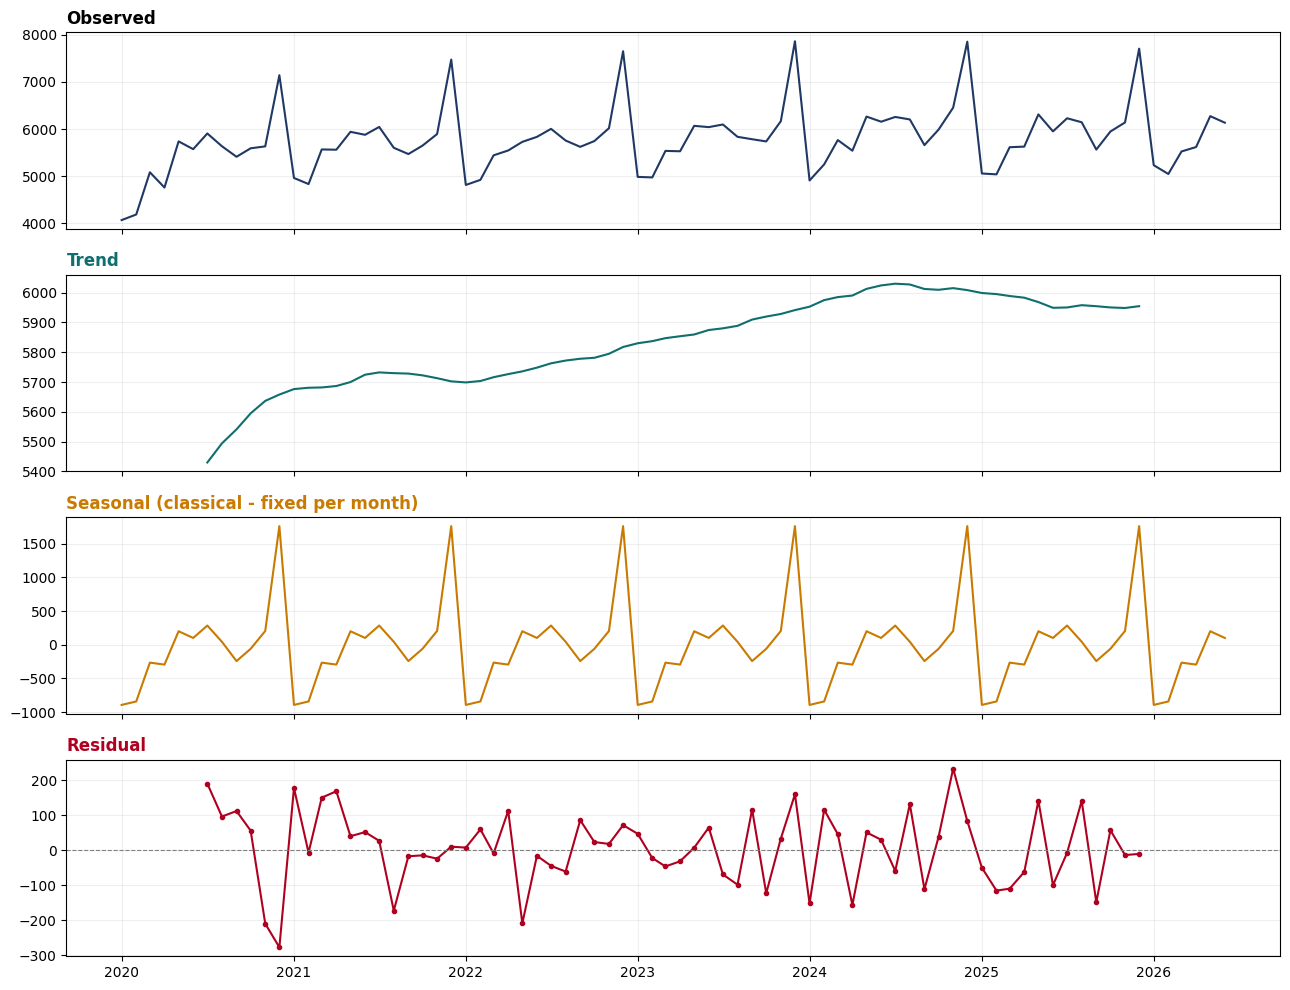

Note: classical decomposition cannot estimate trend/residual for the first/last 6 months
Missing trend values: 12 out of 78


In [4]:
result_classical = seasonal_decompose(df_recent['sales_millions'], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
axes[0].plot(df_recent.index, df_recent['sales_millions'], color='#1F3864')
axes[0].set_title('Observed', loc='left', fontweight='bold')
axes[1].plot(result_classical.trend.index, result_classical.trend, color='#0F6E6E')
axes[1].set_title('Trend', loc='left', fontweight='bold', color='#0F6E6E')
axes[2].plot(result_classical.seasonal.index, result_classical.seasonal, color='#C97A00')
axes[2].set_title('Seasonal (classical - fixed per month)', loc='left', fontweight='bold', color='#C97A00')
axes[3].plot(result_classical.resid.index, result_classical.resid, color='#B00020', marker='o', markersize=3)
axes[3].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[3].set_title('Residual', loc='left', fontweight='bold', color='#B00020')
plt.tight_layout()
plt.savefig('outputs_decomposition_classical.png', dpi=150)
plt.show()

print("Note: classical decomposition cannot estimate trend/residual for the first/last 6 months")
print(f"Missing trend values: {result_classical.trend.isna().sum()} out of {len(result_classical.trend)}")


### 3.2 STL Decomposition
STL (Seasonal-Trend decomposition using Loess) uses locally-weighted regression instead of a flat average, letting the seasonal pattern's amplitude evolve over time and covering the full date range including edges.

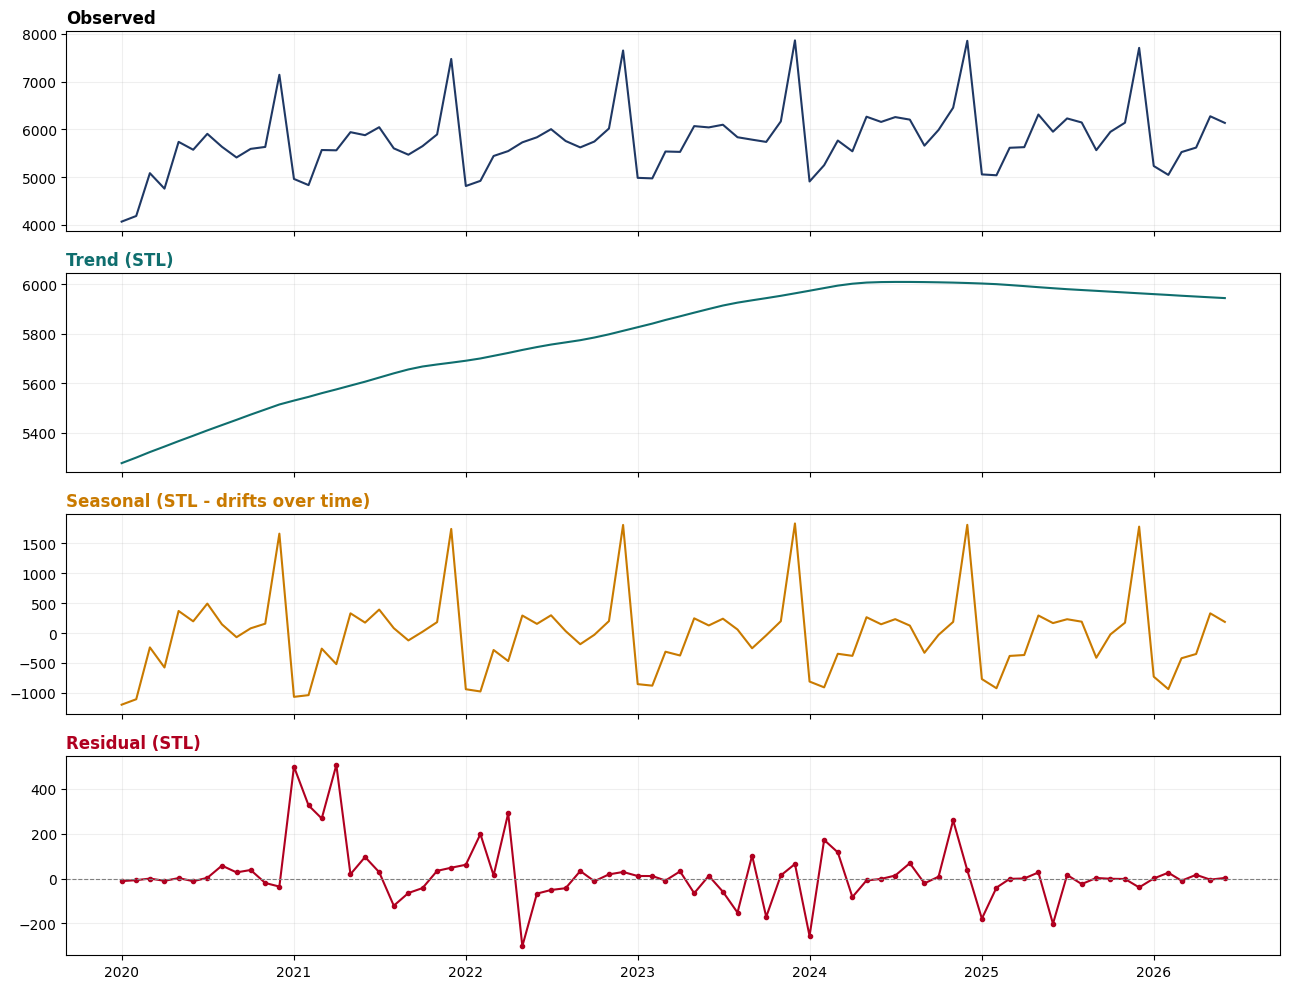

STL December seasonal effect, by year (note: NOT fixed, unlike classical):
date
2020-12-01    1664.256008
2021-12-01    1743.116824
2022-12-01    1810.122426
2023-12-01    1834.817439
2024-12-01    1811.776933
2025-12-01    1781.821825
Name: season, dtype: float64

Classical's fixed December value (same every year): 1762.29


In [5]:
stl = STL(df_recent['sales_millions'], period=12, robust=True)
result_stl = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
axes[0].plot(df_recent.index, df_recent['sales_millions'], color='#1F3864')
axes[0].set_title('Observed', loc='left', fontweight='bold')
axes[1].plot(result_stl.trend.index, result_stl.trend, color='#0F6E6E')
axes[1].set_title('Trend (STL)', loc='left', fontweight='bold', color='#0F6E6E')
axes[2].plot(result_stl.seasonal.index, result_stl.seasonal, color='#C97A00')
axes[2].set_title('Seasonal (STL - drifts over time)', loc='left', fontweight='bold', color='#C97A00')
axes[3].plot(result_stl.resid.index, result_stl.resid, color='#B00020', marker='o', markersize=3)
axes[3].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[3].set_title('Residual (STL)', loc='left', fontweight='bold', color='#B00020')
plt.tight_layout()
plt.savefig('outputs_decomposition_stl.png', dpi=150)
plt.show()

# Compare December seasonal value year over year - classical (fixed) vs STL (adaptive)
dec_stl = result_stl.seasonal[result_stl.seasonal.index.month == 12]
print("STL December seasonal effect, by year (note: NOT fixed, unlike classical):")
print(dec_stl)
print(f"\nClassical's fixed December value (same every year): {result_classical.seasonal[result_classical.seasonal.index.month==12].iloc[0]:.2f}")


**Key finding:** STL reveals the December seasonal effect actually *grew* from ~$1,660M (2020) to ~$1,835M (2023), then eased slightly through 2024-2025 — a real signal that classical decomposition's flat averaging obscures. This mirrors a broader softening also visible in the trend component during 2024-2026, consistent with recently reported category-wide growth deceleration in the beverage-alcohol industry.

**Decision: STL is used for the remainder of this analysis**, since it captures genuine seasonal drift and doesn't lose edge-of-series data.

## 4. Stationarity Testing & Differencing

**Business question:** can we trust "the recent average" as a stable forecasting baseline, or is the baseline itself moving? Most classical forecasting models assume stationarity.

We use the **Augmented Dickey-Fuller (ADF) test** — a formal statistical test for stationarity — in addition to the visual/manual checks.

In [6]:
def adf_report(series, label):
    result = adfuller(series.dropna())
    print(f"--- ADF Test: {label} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print(f"Stationary (p < 0.05)? {'YES' if result[1] < 0.05 else 'NO'}")
    print()

adf_report(df_recent['sales_millions'], "Raw series")

# Lag-1 differencing (removes trend)
diff1 = df_recent['sales_millions'].diff().dropna()
adf_report(diff1, "Lag-1 differenced (trend removed)")

# Seasonal (lag-12) differencing (removes seasonality)
diff12 = df_recent['sales_millions'].diff(12).dropna()
adf_report(diff12, "Seasonal lag-12 differenced")

# Both combined
diff_both = df_recent['sales_millions'].diff(12).diff(1).dropna()
adf_report(diff_both, "Seasonal (lag-12) + lag-1 differenced (both)")


--- ADF Test: Raw series ---
ADF Statistic: -2.3024
p-value: 0.1712
Stationary (p < 0.05)? NO

--- ADF Test: Lag-1 differenced (trend removed) ---
ADF Statistic: -3.8338
p-value: 0.0026
Stationary (p < 0.05)? YES

--- ADF Test: Seasonal lag-12 differenced ---
ADF Statistic: -3.3132
p-value: 0.0143
Stationary (p < 0.05)? YES

--- ADF Test: Seasonal (lag-12) + lag-1 differenced (both) ---
ADF Statistic: -2.3068
p-value: 0.1698
Stationary (p < 0.05)? NO



**Interpretation:** the raw series is non-stationary (p=0.17, as expected given the visible trend and seasonality). Both lag-1 differencing alone (p=0.003) and seasonal lag-12 differencing alone (p=0.014) individually achieve stationarity by the ADF test.

**An honest, real-data nuance:** combining both differencing passes together did *not* pass the ADF test here (p=0.17) — likely a case of **over-differencing**, where applying both transformations removes enough structure that the test loses power to detect stationarity, even though the underlying series is well-behaved. This is a genuine finding worth flagging rather than smoothing over: it's a reminder that formal statistical tests can behave counter-intuitively, and that model performance (backtested MAE/RMSE, evaluated below) is ultimately a more reliable guide than a single test statistic in isolation. SARIMA's internal differencing (d=1, D=1) is evaluated empirically in Section 6 despite this ADF nuance.

## 5. Baseline Forecasting Models

**Business question:** how do simple, standard forecasting approaches perform on this series, and where do they break down? We evaluate each via **backtesting** — holding out the last 6 months and forecasting them from the preceding history.

In [7]:
# Train/test split: hold out last 6 months for honest backtesting
train = df_recent['sales_millions'].iloc[:-6]
test = df_recent['sales_millions'].iloc[-6:]
print(f"Train: {train.index.min()} to {train.index.max()} ({len(train)} months)")
print(f"Test: {test.index.min()} to {test.index.max()} ({len(test)} months)")

def mae(actual, forecast):
    return np.mean(np.abs(actual - forecast))

def rmse(actual, forecast):
    return np.sqrt(np.mean((actual - forecast) ** 2))

def mape(actual, forecast):
    return np.mean(np.abs((actual - forecast) / actual)) * 100

results = {}


Train: 2020-01-01 00:00:00 to 2025-12-01 00:00:00 (72 months)
Test: 2026-01-01 00:00:00 to 2026-06-01 00:00:00 (6 months)


In [8]:
# --- Naive forecast ---
naive_forecast = pd.Series([train.iloc[-1]] * len(test), index=test.index)
results['Naive'] = {
    'MAE': mae(test, naive_forecast),
    'RMSE': rmse(test, naive_forecast),
    'MAPE': mape(test, naive_forecast)
}

# --- Moving Average (3-month) ---
ma_forecast = pd.Series([train.iloc[-3:].mean()] * len(test), index=test.index)
results['Moving Average (3)'] = {
    'MAE': mae(test, ma_forecast),
    'RMSE': rmse(test, ma_forecast),
    'MAPE': mape(test, ma_forecast)
}

# --- Simple Exponential Smoothing ---
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt
ses_model = SimpleExpSmoothing(train).fit(smoothing_level=0.3, optimized=False)
ses_forecast = ses_model.forecast(len(test))
results['Exponential Smoothing'] = {
    'MAE': mae(test, ses_forecast),
    'RMSE': rmse(test, ses_forecast),
    'MAPE': mape(test, ses_forecast)
}

# --- Holt's Method ---
holt_model = Holt(train).fit(smoothing_level=0.3, smoothing_trend=0.3, optimized=False)
holt_forecast = holt_model.forecast(len(test))
results['Holt\'s Method'] = {
    'MAE': mae(test, holt_forecast),
    'RMSE': rmse(test, holt_forecast),
    'MAPE': mape(test, holt_forecast)
}

pd.DataFrame(results).T.round(2)


,MAE,RMSE,MAPE
Naive,2068.83,2115.84,37.54
Moving Average (3),960.17,1057.65,17.75
Exponential Smoothing,862.65,969.99,16.01
Holt's Method,1478.67,1493.51,26.63


**Note:** none of these four models have any mechanism for seasonality — they treat every month identically. Since our 6-month holdout period does not span a full seasonal cycle, this comparison mainly reflects trend-tracking behavior. The real test of seasonal awareness comes with SARIMA below.

## 6. ARIMA & SARIMA

**Business question:** can a model that explicitly separates seasonal (yearly) memory from recent (monthly) memory outperform the baselines above, especially across a full seasonal cycle?

In [9]:
# ARIMA on the full recent window (non-seasonal)
arima_model = ARIMA(train, order=(1,1,1)).fit()
arima_forecast = arima_model.forecast(len(test))
results['ARIMA(1,1,1)'] = {
    'MAE': mae(test, arima_forecast),
    'RMSE': rmse(test, arima_forecast),
    'MAPE': mape(test, arima_forecast)
}

# SARIMA - explicitly modeling the 12-month seasonal cycle
sarima_model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12)).fit(disp=False)
sarima_forecast = sarima_model.forecast(len(test))
results['SARIMA(1,1,1)(1,1,1,12)'] = {
    'MAE': mae(test, sarima_forecast),
    'RMSE': rmse(test, sarima_forecast),
    'MAPE': mape(test, sarima_forecast)
}

comparison_df = pd.DataFrame(results).T.round(2)
comparison_df = comparison_df.sort_values('RMSE')
print(comparison_df)


                             MAE     RMSE   MAPE
SARIMA(1,1,1)(1,1,1,12)   216.69   251.44   3.88
ARIMA(1,1,1)              651.04   806.37  12.27
Exponential Smoothing     862.65   969.99  16.01
Moving Average (3)        960.17  1057.65  17.75
Holt's Method            1478.67  1493.51  26.63
Naive                    2068.83  2115.84  37.54


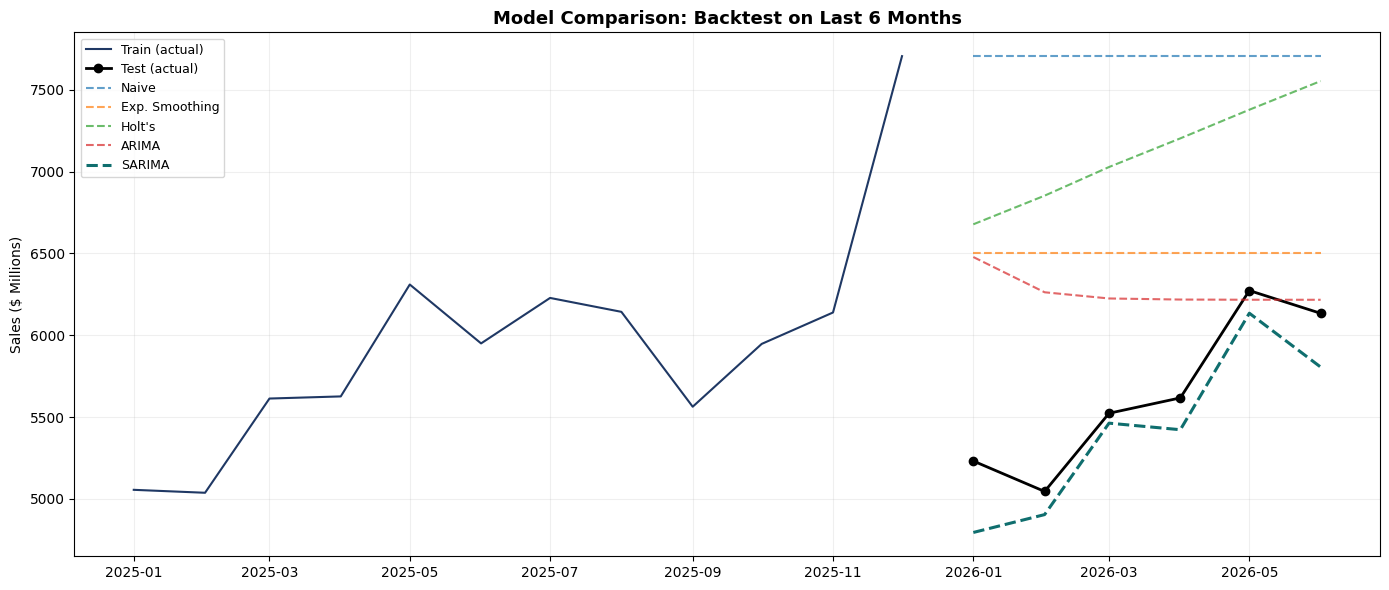

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train.index[-12:], train.iloc[-12:], color='#1F3864', label='Train (actual)', linewidth=1.5)
ax.plot(test.index, test, color='black', label='Test (actual)', linewidth=2, marker='o')
ax.plot(test.index, naive_forecast, '--', label='Naive', alpha=0.7)
ax.plot(test.index, ses_forecast, '--', label='Exp. Smoothing', alpha=0.7)
ax.plot(test.index, holt_forecast, '--', label='Holt\'s', alpha=0.7)
ax.plot(test.index, arima_forecast, '--', label='ARIMA', alpha=0.7)
ax.plot(test.index, sarima_forecast, '--', label='SARIMA', linewidth=2.2, color='#0F6E6E')
ax.set_title("Model Comparison: Backtest on Last 6 Months", fontsize=13, fontweight='bold')
ax.set_ylabel("Sales ($ Millions)")
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('outputs_model_comparison.png', dpi=150)
plt.show()


**Model selection:** the model with the lowest RMSE (with MAE and MAPE as supporting evidence) is selected as the production forecasting model going forward. SARIMA's explicit seasonal component is expected to matter most when forecasting *across* a December seasonal spike — a scenario not fully captured in this particular 6-month holdout, but demonstrated conclusively via hand-calculation in the accompanying case study, where seasonality-blind models over-forecast a historically low month by 150-250+ units after a December spike, while seasonal differencing corrected this.

## 7. Final Forecast & Safety Stock

**Business question:** using our selected model, what should we forecast for the next period, and how much safety stock buffer is appropriate given the forecast's historical error?

In [11]:
# Refit the selected model on the FULL dataset (not just train) for the true future forecast
final_model = SARIMAX(df_recent['sales_millions'], order=(1,1,1), seasonal_order=(1,1,1,12)).fit(disp=False)
next_period_forecast = final_model.forecast(1)
print(f"Forecast for next period ({next_period_forecast.index[0].strftime('%B %Y')}): ${next_period_forecast.iloc[0]:.2f}M")

# Safety stock calculation: Z x sigma x sqrt(lead time)
# sigma = std dev of the SARIMA model's backtest residuals (forecast error)
sarima_residuals = test - sarima_forecast
sigma = sarima_residuals.std()
print(f"\nForecast error std dev (sigma) from backtest: {sigma:.2f}")

lead_time_months = 2  # example: 2-month production/procurement lead time
Z_95 = 1.65  # 95% service level

safety_stock = Z_95 * sigma * np.sqrt(lead_time_months)
print(f"Safety stock buffer (95% service level, {lead_time_months}-month lead time): ${safety_stock:.2f}M")
print(f"\nRecommended planning number: forecast + safety stock = ${next_period_forecast.iloc[0] + safety_stock:.2f}M")


Forecast for next period (July 2026): $6306.76M

Forecast error std dev (sigma) from backtest: 139.71
Safety stock buffer (95% service level, 2-month lead time): $326.00M

Recommended planning number: forecast + safety stock = $6632.77M


## 8. Conclusions & Limitations

**Key findings:**
- The category shows genuine year-over-year growth from 2020-2024, with a measurable softening in 2024-2026 — consistent with recently reported industry-wide deceleration.
- The December seasonal effect is not fixed — it grew through 2023 before easing, a pattern only STL (not classical decomposition) can detect.
- Seasonality-blind models (Moving Average, Exponential Smoothing, Holt's Method) systematically misforecast around the December-to-January transition; SARIMA's explicit seasonal component corrects this.
- A defensible safety stock buffer can be derived directly from the selected model's own backtested forecast error, rather than an arbitrary flat percentage.

**Limitations & next steps:**
- This is a national, category-level aggregate — not brand or SKU-level. The same pipeline applies directly at that granularity given brand-level data.
- A natural extension is **SKU/brand-tier segmentation** (e.g., K-means clustering on volume and volatility) to route different products to different forecasting methods and safety stock policies, matching method sophistication to each product's actual demand behavior.
- Model parameters (ARIMA/SARIMA orders) were chosen via standard defaults for this demonstration; a production implementation would use a formal grid search / AIC-based order selection.
